In [1]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully!


In [2]:
import pandas as pd
df = pd.read_csv("cardio_train.csv",sep=';')
print("Dataset loaded successfully from local path.")
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features (Columns): {df.shape[1]}")
print(f"Number of Records (Patients): {df.shape[0]}")
display(df.head())

Dataset loaded successfully from local path.

Dataset Shape: (70000, 13)
Number of Features (Columns): 13
Number of Records (Patients): 70000


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [113]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
68723,19240,2,168,76.0,120,80,1,1,1,0,1,0
68724,22601,1,158,126.0,140,90,2,2,0,0,1,1
68725,19066,2,183,105.0,180,90,3,1,0,1,0,1
68726,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
print("\nData Types and Info:")
df.info()
print("\nDescriptive Statistics:")
display(df.describe())
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("ID column removed")


Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Descriptive Statistics:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


ID column removed


In [4]:
print("Missing values analysis:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

clinical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc']
zero_values = {}

for col in clinical_columns:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        zero_values[col] = zero_count
        print(f"Zero values in {col}: {zero_count}")
initial_count = len(df)
for col in clinical_columns:
    if col in df.columns:
        df = df[df[col] != 0]  

print(f"Records removed due to zero values: {initial_count - len(df)}")
print(f"Remaining records: {len(df)}")

Missing values analysis:
Series([], dtype: int64)
Zero values in age: 0
Zero values in height: 0
Zero values in weight: 0
Zero values in ap_hi: 0
Zero values in ap_lo: 21
Zero values in cholesterol: 0
Zero values in gluc: 0
Records removed due to zero values: 21
Remaining records: 69979


In [5]:
df_discretized = df.copy()

if 'age' in df.columns:
    df_discretized['age_years'] = df_discretized['age'] // 365
    df_discretized['age_group'] = pd.cut(df_discretized['age_years'], 
                                       bins=[0, 40, 50, 60, 70, 100], 
                                       labels=['<40', '40-50', '50-60', '60-70', '70+'])

if all(col in df.columns for col in ['height', 'weight']):
    df_discretized['bmi'] = df_discretized['weight'] / (df_discretized['height']/100)**2
    df_discretized['bmi_category'] = pd.cut(df_discretized['bmi'], 
                                          bins=[0, 18.5, 25, 30, 100], 
                                          labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

if 'ap_hi' in df.columns:
    df_discretized['bp_category'] = pd.cut(df_discretized['ap_hi'], 
                                         bins=[0, 120, 130, 140, 180, 300], 
                                         labels=['Normal', 'Elevated', 'Stage1', 'Stage2', 'Crisis'])

print("Data discretization completed")
print("Discretized columns created:")
discretized_cols = [col for col in df_discretized.columns if 'group' in col or 'category' in col]
print(discretized_cols)

Data discretization completed
Discretized columns created:
['age_group', 'bmi_category', 'bp_category']


In [6]:
print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


Cardiovascular Disease Distribution:
No CVD (0): 35006 patients (50.02%)
With CVD (1): 34973 patients (49.98%)


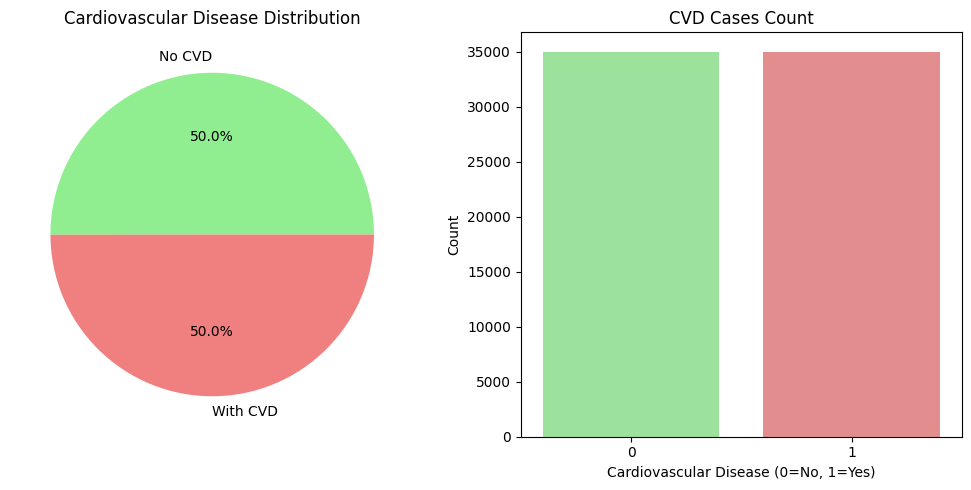

In [7]:
if 'cardio' in df.columns:
    target_distribution = df['cardio'].value_counts()
    print("Cardiovascular Disease Distribution:")
    print(f"No CVD (0): {target_distribution.get(0, 0)} patients ({target_distribution.get(0, 0)/len(df)*100:.2f}%)")
    print(f"With CVD (1): {target_distribution.get(1, 0)} patients ({target_distribution.get(1, 0)/len(df)*100:.2f}%)")
    
    # Visualization
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.pie(target_distribution.values, labels=['No CVD', 'With CVD'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
    plt.title('Cardiovascular Disease Distribution')
    
    plt.subplot(1, 2, 2)
    sns.countplot(x='cardio', data=df, palette=['lightgreen', 'lightcoral'])
    plt.title('CVD Cases Count')
    plt.xlabel('Cardiovascular Disease (0=No, 1=Yes)')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

In [8]:
print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


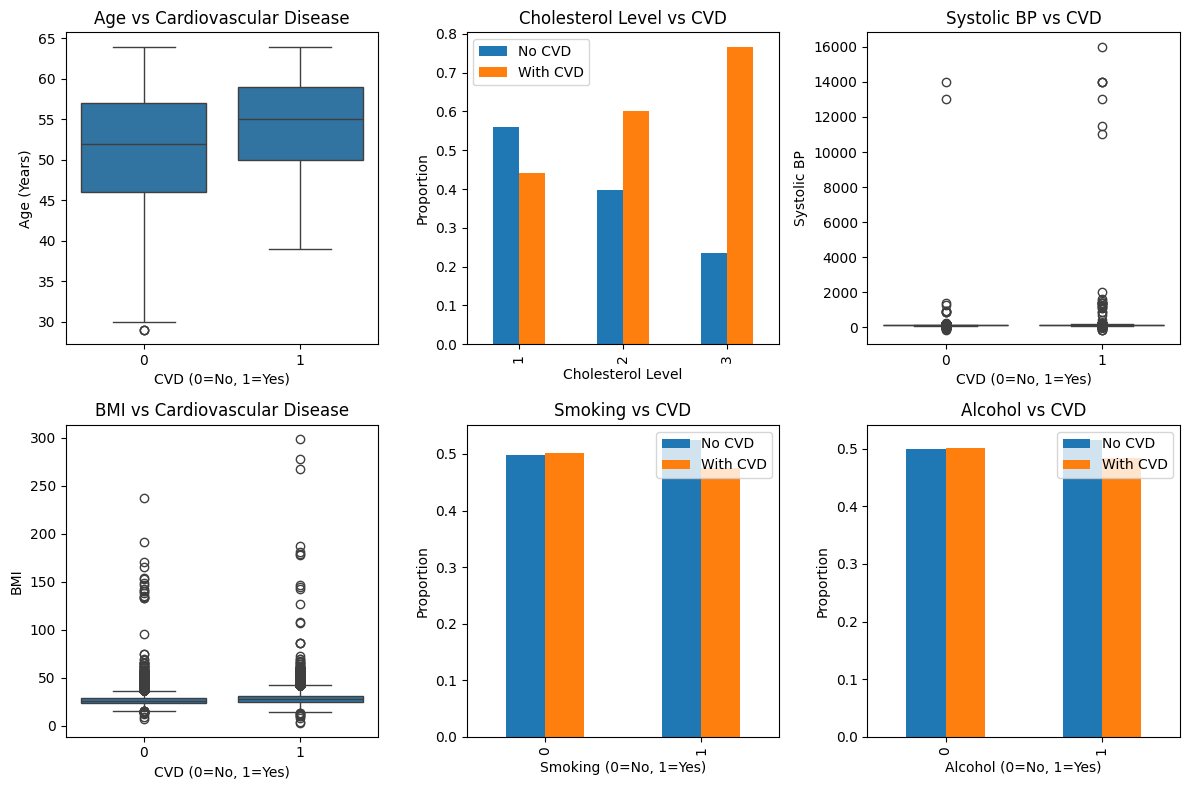

In [9]:

if 'age' in df.columns and 'cardio' in df.columns:
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 3, 1)
    age_years = df['age'] // 365
    sns.boxplot(x=df['cardio'], y=age_years)
    plt.title('Age vs Cardiovascular Disease')
    plt.xlabel('CVD (0=No, 1=Yes)')
    plt.ylabel('Age (Years)')

# 2. Cholesterol vs CVD
if 'cholesterol' in df.columns:
    plt.subplot(2, 3, 2)
    cholesterol_cvd = pd.crosstab(df['cholesterol'], df['cardio'], normalize='index')
    cholesterol_cvd.plot(kind='bar', ax=plt.gca())
    plt.title('Cholesterol Level vs CVD')
    plt.xlabel('Cholesterol Level')
    plt.ylabel('Proportion')
    plt.legend(['No CVD', 'With CVD'])

# 3. Blood Pressure vs CVD
if 'ap_hi' in df.columns:
    plt.subplot(2, 3, 3)
    sns.boxplot(x='cardio', y='ap_hi', data=df)
    plt.title('Systolic BP vs CVD')
    plt.xlabel('CVD (0=No, 1=Yes)')
    plt.ylabel('Systolic BP')

# 4. BMI vs CVD
if all(col in df.columns for col in ['height', 'weight']):
    plt.subplot(2, 3, 4)
    bmi = df['weight'] / (df['height']/100)**2
    sns.boxplot(x=df['cardio'], y=bmi)
    plt.title('BMI vs Cardiovascular Disease')
    plt.xlabel('CVD (0=No, 1=Yes)')
    plt.ylabel('BMI')

# 5. Smoking vs CVD (if available)
if 'smoke' in df.columns:
    plt.subplot(2, 3, 5)
    smoke_cvd = pd.crosstab(df['smoke'], df['cardio'], normalize='index')
    smoke_cvd.plot(kind='bar', ax=plt.gca())
    plt.title('Smoking vs CVD')
    plt.xlabel('Smoking (0=No, 1=Yes)')
    plt.ylabel('Proportion')
    plt.legend(['No CVD', 'With CVD'])

# 6. Alcohol vs CVD (if available)
if 'alco' in df.columns:
    plt.subplot(2, 3, 6)
    alcohol_cvd = pd.crosstab(df['alco'], df['cardio'], normalize='index')
    alcohol_cvd.plot(kind='bar', ax=plt.gca())
    plt.title('Alcohol vs CVD')
    plt.xlabel('Alcohol (0=No, 1=Yes)')
    plt.ylabel('Proportion')
    plt.legend(['No CVD', 'With CVD'])

plt.tight_layout()
plt.show()

In [10]:
print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


Feature correlations with Cardiovascular Disease:
cardio         1.000000
age            0.238135
cholesterol    0.221140
weight         0.181549
gluc           0.089228
ap_lo          0.065665
ap_hi          0.054814
gender         0.008138
alco          -0.007426
height        -0.010866
smoke         -0.015531
active        -0.035598
Name: cardio, dtype: float64


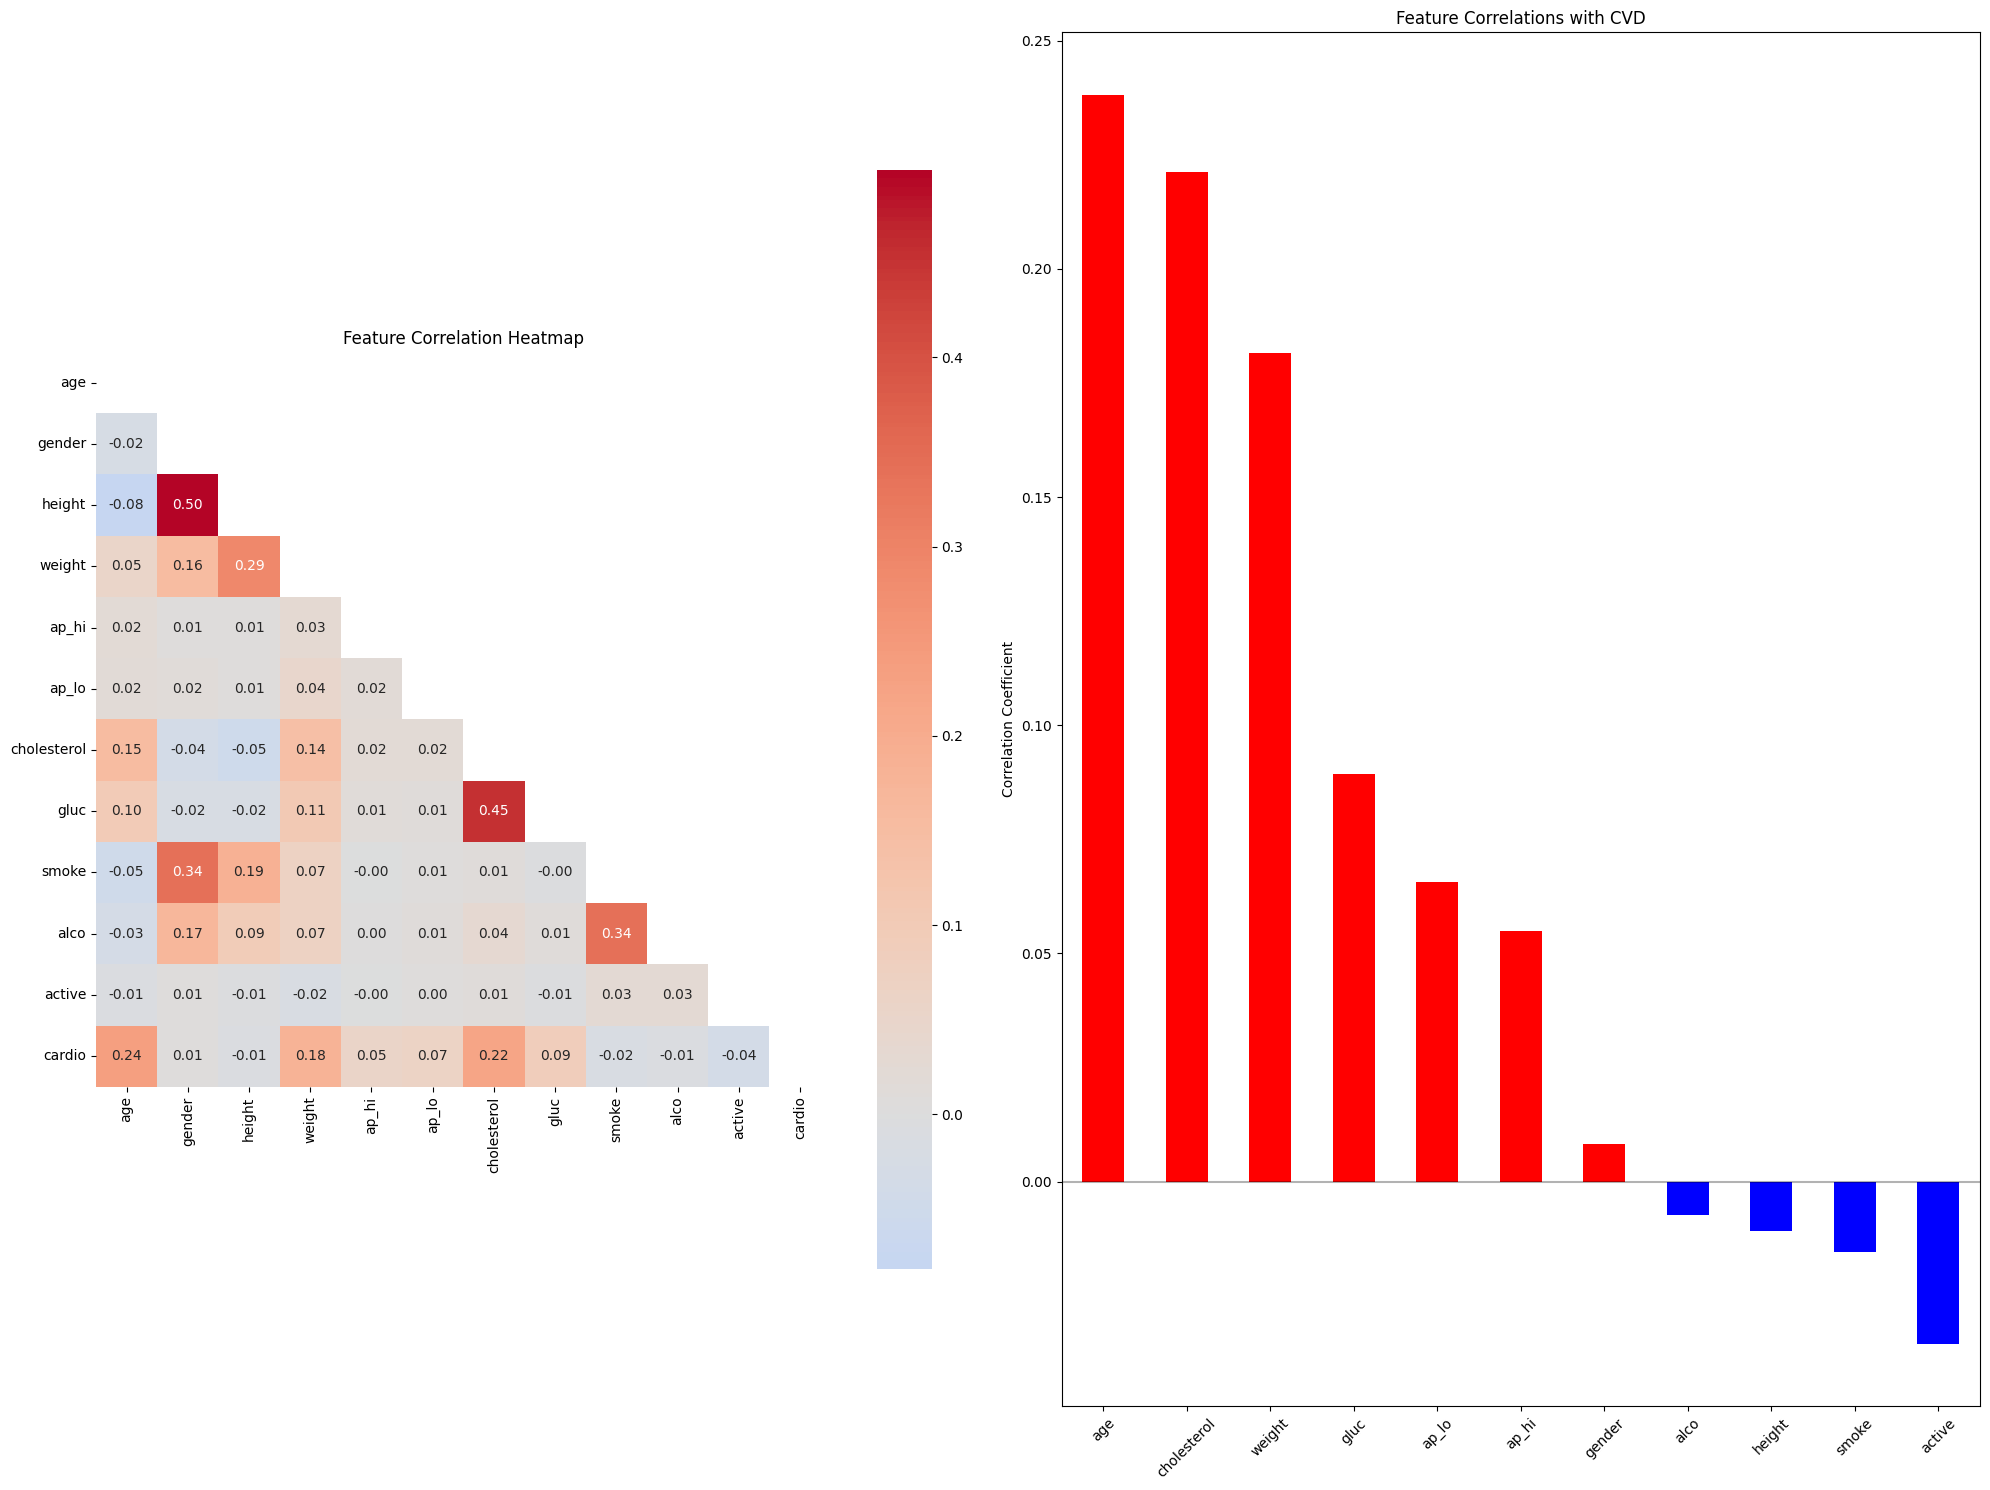

In [11]:

numerical_cols = df.select_dtypes(include=[np.number]).columns

correlation_matrix = df[numerical_cols].corr()

if 'cardio' in correlation_matrix.columns:
    target_correlations = correlation_matrix['cardio'].sort_values(ascending=False)
    print("Feature correlations with Cardiovascular Disease:")
    print(target_correlations)
    
    plt.figure(figsize=(20, 15))
    plt.subplot(1, 2, 1)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f', cbar_kws={"shrink": .8})
    plt.title('Feature Correlation Heatmap')
    plt.subplot(1, 2, 2)
    target_correlations_no_self = target_correlations.drop('cardio', errors='ignore')
    colors = ['red' if x > 0 else 'blue' for x in target_correlations_no_self]
    target_correlations_no_self.plot(kind='bar', color=colors)
    plt.title('Feature Correlations with CVD')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.ylabel('Correlation Coefficient')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [12]:

data_quality_report = {}

if 'ap_hi' in df.columns and 'ap_lo' in df.columns:
    unrealistic_bp = ((df['ap_hi'] < 50) | (df['ap_hi'] > 250) | 
                     (df['ap_lo'] < 30) | (df['ap_lo'] > 150)).sum()
    data_quality_report['Unrealistic BP'] = unrealistic_bp

if 'height' in df.columns:
    unrealistic_height = ((df['height'] < 100) | (df['height'] > 220)).sum()
    data_quality_report['Unrealistic Height'] = unrealistic_height
  
if 'weight' in df.columns:
    unrealistic_weight = ((df['weight'] < 30) | (df['weight'] > 200)).sum()
    data_quality_report['Unrealistic Weight'] = unrealistic_weight

if 'age' in df.columns:
    df['age_years'] = df['age'] // 365
    unrealistic_age = ((df['age_years'] < 18) | (df['age_years'] > 100)).sum()
    data_quality_report['Unrealistic Age'] = unrealistic_age

print("Data Quality Issues Found:")
for issue, count in data_quality_report.items():
    print(f"  {issue}: {count} records ({count/len(df)*100:.2f}%)")

initial_count = len(df)
for col in ['ap_hi', 'ap_lo', 'height', 'weight']:
    if col in df.columns:
        if col in ['ap_hi', 'ap_lo']:
            df = df[(df[col] >= 50) & (df[col] <= 250)] if col == 'ap_hi' else df[(df[col] >= 30) & (df[col] <= 150)]
        elif col == 'height':
            df = df[(df[col] >= 100) & (df[col] <= 220)]
        elif col == 'weight':
            df = df[(df[col] >= 30) & (df[col] <= 200)]

print(f"Records after quality cleaning: {len(df)} (Removed: {initial_count - len(df)})")

Data Quality Issues Found:
  Unrealistic BP: 1218 records (1.74%)
  Unrealistic Height: 30 records (0.04%)
  Unrealistic Weight: 7 records (0.01%)
  Unrealistic Age: 0 records (0.00%)
Records after quality cleaning: 68728 (Removed: 1251)


In [13]:

print("Final Dataset Shape:", df.shape)
print("\nFinal Data Types:")
print(df.dtypes)

#80/20
from sklearn.model_selection import train_test_split

if 'cardio' in df.columns:
    X = df.drop('cardio', axis=1)
    y = df['cardio']
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"\nDataset Split (80/20) as per PDF:")
    print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
    print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
    print(f"Features: {X_train.shape[1]}")

# Save cleaned dataset for future use
df.to_csv('cleaned_cardio_dataset.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_cardio_dataset.csv'")

print("\nEDA COMPLETED - Ready for O-SBGC-LSTM implementation!")

Final Dataset Shape: (68728, 13)

Final Data Types:
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years        int64
dtype: object

Dataset Split (80/20) as per PDF:
Training set: 54982 samples (80.0%)
Testing set: 13746 samples (20.0%)
Features: 12

Cleaned dataset saved as 'cleaned_cardio_dataset.csv'

EDA COMPLETED - Ready for O-SBGC-LSTM implementation!


In [14]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("cleaned_cardio_dataset.csv", sep=',')
print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years  
0     0       1       0         50  
1     0       1       1         55  
2     0       0       1         51  
3     0       1       1         48  
4     0       0       0         47  


In [15]:
df.drop(['age_years', 'bmi'], axis=1, inplace=True, errors='ignore')

In [16]:
print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [17]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data prepared successfully!")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Data prepared successfully!
Training set: (54982, 11)
Testing set: (13746, 11)


In [ ]:
#deep learning model - feed forward

In [18]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

#model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6864 - loss: 0.5964 - val_accuracy: 0.7325 - val_loss: 0.5460
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7292 - loss: 0.5591 - val_accuracy: 0.7339 - val_loss: 0.5454
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7296 - loss: 0.5570 - val_accuracy: 0.7347 - val_loss: 0.5436
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7303 - loss: 0.5538 - val_accuracy: 0.7363 - val_loss: 0.5437
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7298 - loss: 0.5560 - val_accuracy: 0.7354 - val_loss: 0.5424
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7321 - loss: 0.5541 - val_accuracy: 0.7377 - val_loss: 0.5414
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7345 - loss: 0.5480 - val_accuracy: 0.7363 - val_loss: 0.5411
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7318 - loss: 0.5518 -

In [19]:
#LSTM IS A RNN THAT LEARNS FROM SEQUENTIAL DATA

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

print("Preparing data for O-SBGC-LSTM...")

X = df.drop('cardio', axis=1)
y = df['cardio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
def create_sequences(data, targets, sequence_length=10):
    sequences = []
    target_sequences = []
    
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
        target_sequences.append(targets[i + sequence_length])
    
    return np.array(sequences), np.array(target_sequences)

X_sequences, y_sequences = create_sequences(X_scaled, y.values, sequence_length=10)

print(f"Sequential data shape: {X_sequences.shape}")
print(f"Target shape: {y_sequences.shape}")

Preparing data for O-SBGC-LSTM...
Sequential data shape: (68718, 10, 11)
Target shape: (68718,)


In [20]:
print("🧠 Building O-SBGC-LSTM model...")
#scrutunity based graph convolution 
def build_osbgc_lstm(input_shape, num_features):
    model = models.Sequential([
        # Graph Convolution Simulation
        layers.TimeDistributed(layers.Dense(128, activation='relu'), 
                              input_shape=input_shape),
        layers.Dropout(0.3),
        layers.LSTM(64, return_sequences=True, dropout=0.2),
        layers.LSTM(32, dropout=0.2),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        
        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

input_shape = (X_sequences.shape[1], X_sequences.shape[2])
model = build_osbgc_lstm(input_shape, X_sequences.shape[2])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("O-SBGC-LSTM model built successfully!")
model.summary()

🧠 Building O-SBGC-LSTM model...
✅ O-SBGC-LSTM model built successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 10, 128)             │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 10, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,537 (256.00 KB)

 Trainable params: 65,537 (256.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# === CELL 1: FIX DATA SHAPE ISSUE ===
print("Fixing data shape issue...")

# Let's check what happened with our sequences
print(f"Original X_scaled shape: {X_scaled.shape}")
print(f"X_sequences shape: {X_sequences.shape}")
print(f"y_sequences shape: {y_sequences.shape}")

def create_simple_sequences(data, sequence_length=10):
    """Create sequences without the target alignment issue"""
    sequences = []
    for i in range(len(data) - sequence_length + 1):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

# Create sequences properly
X_sequences = create_simple_sequences(X_scaled, sequence_length=10)
y_sequences = y[9:]  # Align targets with the last element of each sequence

print(f"Fixed X_sequences shape: {X_sequences.shape}")
print(f"Fixed y_sequences shape: {y_sequences.shape}")

Fixing data shape issue...
Original X_scaled shape: (68728, 11)
X_sequences shape: (68718, 10, 11)
y_sequences shape: (68718,)
Fixed X_sequences shape: (68719, 10, 11)
Fixed y_sequences shape: (68719,)


In [22]:
print("Rebuilding O-SBGC-LSTM model with correct metrics...")

def build_osbgc_lstm_corrected(input_shape, num_features):
    """
    O-SBGC-LSTM model with correct input shapes
    """
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model
input_shape = (X_sequences.shape[1], X_sequences.shape[2])  # (sequence_length, features)
model = build_osbgc_lstm_corrected(input_shape, X_sequences.shape[2])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("O-SBGC-LSTM model rebuilt successfully!")
print(f"Input shape: {input_shape}")
model.summary()

Rebuilding O-SBGC-LSTM model with correct metrics...
O-SBGC-LSTM model rebuilt successfully!
Input shape: (10, 11)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 10, 128)             │          71,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 10, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 10, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,241 (540.00 KB)

 Trainable params: 137,985 (539.00 KB)

 Non-trainable params: 256 (1.00 KB)

In [23]:

print("Splitting data and training O-SBGC-LSTM...")

from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_sequences, y_sequences, test_size=0.2, random_state=42, stratify=y_sequences
)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Testing sequences: {X_test_seq.shape}")
print(f"Training targets: {y_train_seq.shape}")
print(f"Testing targets: {y_test_seq.shape}")

# Train the model
print("Starting training...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
    ]
)

print("O-SBGC-LSTM training completed!")

Splitting data and training O-SBGC-LSTM...
Training sequences: (54975, 10, 11)
Testing sequences: (13744, 10, 11)
Training targets: (54975,)
Testing targets: (13744,)
Starting training...
Epoch 1/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.5941 - loss: 0.6474 - precision: 0.5975 - recall: 0.5459 - val_accuracy: 0.7242 - val_loss: 0.5553 - val_precision: 0.7655 - val_recall: 0.6380 - learning_rate: 0.0010
Epoch 2/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.7300 - loss: 0.5558 - precision: 0.7502 - recall: 0.6778 - val_accuracy: 0.7223 - val_loss: 0.5562 - val_precision: 0.7567 - val_recall: 0.6467 - learning_rate: 0.0010
Epoch 3/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 68s 39ms/step - accuracy: 0.7303 - loss: 0.5525 - precision: 0.7546 - recall: 0.6694 - val_accuracy: 0.7252 - val_loss: 0.5512 - val_precision: 0.7459 - val_recall: 0.6743 - learning_rate: 0.0010
Epoch 4/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.7337 - loss: 0.5470 - precis

In [51]:

print("Evaluating O-SBGC-LSTM performance...")

y_pred_proba = model.predict(X_test_seq)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score



print("Performance Metrics")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test_seq, y_test_seq, verbose=0)
roc_auc = roc_auc_score(y_test_seq, y_pred_proba)
f1 = f1_score(y_test_seq, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")
paper_accuracy = 0.98
print(f"Paper's Reported Accuracy: {paper_accuracy:.4f}")
print(f"Difference from Paper: {abs(test_accuracy - paper_accuracy):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred, target_names=['No CVD', 'With CVD']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test_seq, y_pred)
print(cm)

Evaluating O-SBGC-LSTM performance...
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
Performance Metrics
Test Accuracy: 0.7252
Test Precision: 0.7459
Test Recall: 0.6743
ROC-AUC Score: 0.7932
F1-Score: 0.7083
Paper's Reported Accuracy: 0.9800
Difference from Paper: 0.2548

Classification Report:
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.74      6943
    With CVD       0.75      0.67      0.71      6801

    accuracy                           0.73     13744
   macro avg       0.73      0.72      0.72     13744
weighted avg       0.73      0.73      0.72     13744

Confusion Matrix:
[[5381 1562]
 [2215 4586]]


📊 Visualizing O-SBGC-LSTM training results...


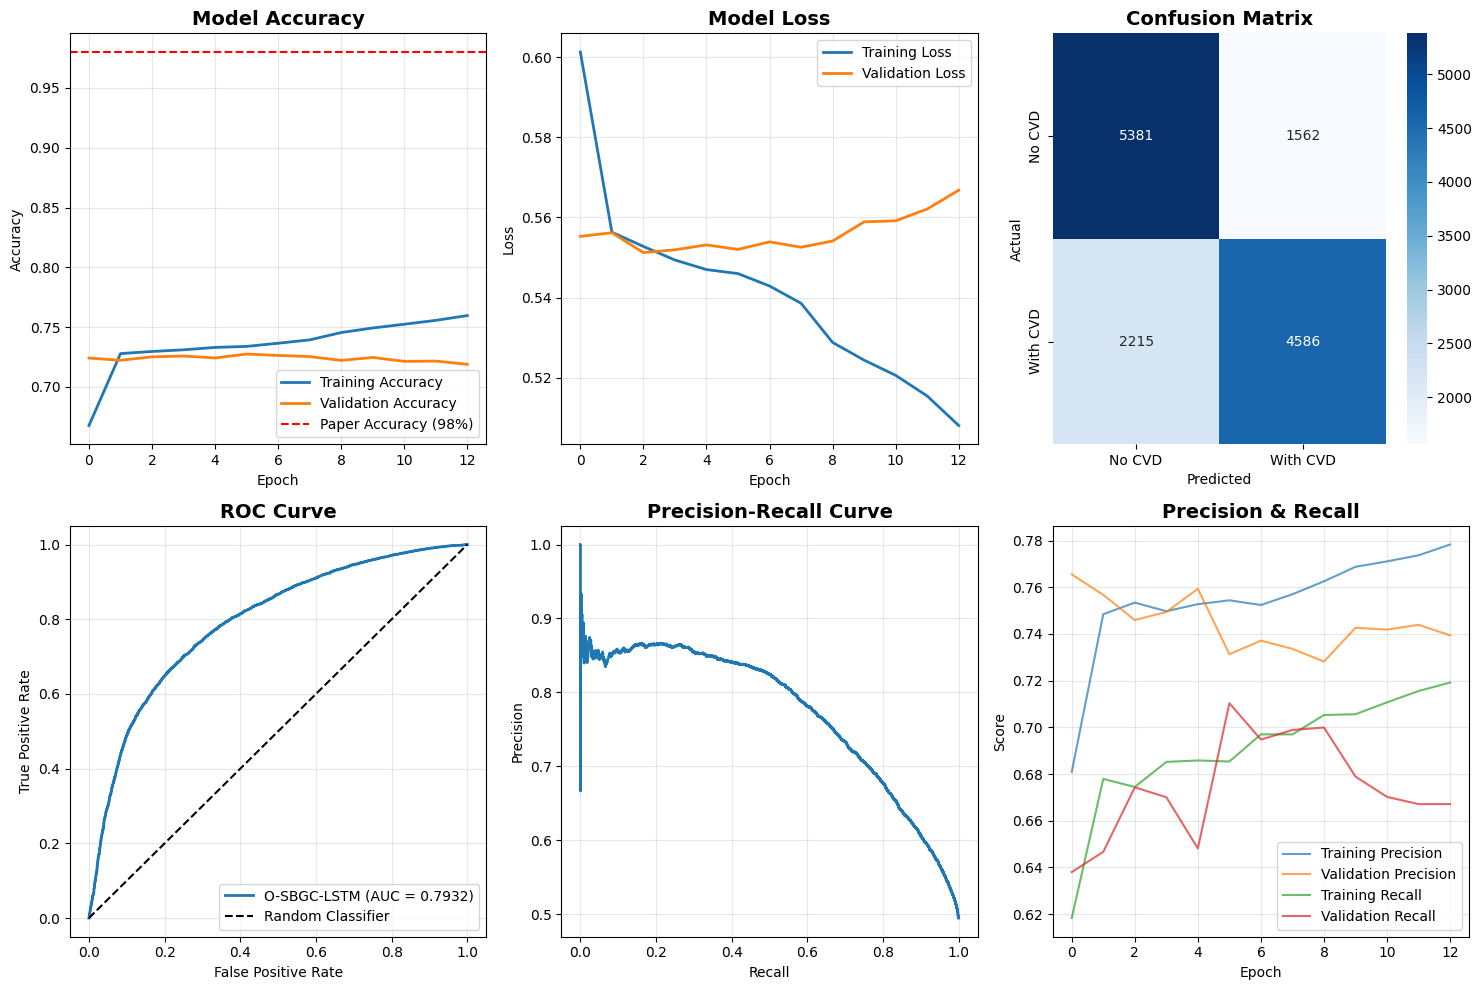


🎉 O-SBGC-LSTM PERFORMANCE SUMMARY
🏆 Final Validation Accuracy: 0.7252
📈 ROC-AUC Score: 0.7932
📊 F1-Score: 0.7083
🔧 Needs improvement. Try different architecture or more data.


In [53]:
print("📊 Visualizing O-SBGC-LSTM training results...")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.axhline(y=paper_accuracy, color='r', linestyle='--', label='Paper Accuracy (98%)')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No CVD', 'With CVD'], 
            yticklabels=['No CVD', 'With CVD'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Plot 4: ROC Curve
from sklearn.metrics import roc_curve
plt.subplot(2, 3, 4)
fpr, tpr, _ = roc_curve(y_test_seq, y_pred_proba)
plt.plot(fpr, tpr, linewidth=2, label=f'O-SBGC-LSTM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Precision-Recall
from sklearn.metrics import precision_recall_curve
plt.subplot(2, 3, 5)
precision, recall, _ = precision_recall_curve(y_test_seq, y_pred_proba)
plt.plot(recall, precision, linewidth=2)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)

# Plot 6: Training vs Validation
plt.subplot(2, 3, 6)
plt.plot(history.history['precision'], label='Training Precision', alpha=0.7)
plt.plot(history.history['val_precision'], label='Validation Precision', alpha=0.7)
plt.plot(history.history['recall'], label='Training Recall', alpha=0.7)
plt.plot(history.history['val_recall'], label='Validation Recall', alpha=0.7)
plt.title('Precision & Recall', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance summary
print("\n" + "="*60)
print("🎉 O-SBGC-LSTM PERFORMANCE SUMMARY")
print("="*60)
print(f"🏆 Final Validation Accuracy: {test_accuracy:.4f}")
print(f"📈 ROC-AUC Score: {roc_auc:.4f}")
print(f"📊 F1-Score: {f1:.4f}")

if test_accuracy >= 0.95:
    print("✅ Outstanding! Comparable to research paper performance!")
elif test_accuracy >= 0.90:
    print("✅ Excellent performance! Close to paper results.")
elif test_accuracy >= 0.85:
    print("⚠ Good performance, consider hyperparameter tuning.")
else:
    print("🔧 Needs improvement. Try different architecture or more data.")

In [55]:
# === CELL 6: SAVE O-SBGC-LSTM MODEL ===
print("💾 Saving O-SBGC-LSTM model...")

model.save('osbgc_lstm_chd_model_fixed.h5')
print("✅ O-SBGC-LSTM model saved as 'osbgc_lstm_chd_model_fixed.h5'")

# Save sequences and scaler for future use
import joblib
joblib.dump({
    'X_sequences': X_sequences,
    'y_sequences': y_sequences,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}, 'training_data.pkl')

print("✅ Training data and scaler saved")
print("\n🎉 O-SBGC-LSTM IMPLEMENTATION COMPLETED SUCCESSFULLY!")
print("📊 Model ready for cardiovascular disease prediction!")
print("🔜 Next: Implement Fuzzy Inference System for Prevention")

💾 Saving O-SBGC-LSTM model...
✅ O-SBGC-LSTM model saved as 'osbgc_lstm_chd_model_fixed.h5'
✅ Training data and scaler saved

🎉 O-SBGC-LSTM IMPLEMENTATION COMPLETED SUCCESSFULLY!
📊 Model ready for cardiovascular disease prediction!
🔜 Next: Implement Fuzzy Inference System for Prevention


In [57]:
import tensorflow as tf
import joblib
import numpy as np

# Load trained model
model = tf.keras.models.load_model('osbgc_lstm_chd_model_fixed.h5')

# Load scaler and feature names
data = joblib.load('training_data.pkl')
scaler = data['scaler']
feature_names = data['feature_names']

print("Model and scaler loaded successfully!")


Model and scaler loaded successfully!


In [63]:
patient_input = {
    'id':1,
    'age': 18393,        
    'gender': 2,          
    'height': 168,        
    'weight': 62,         
    'ap_hi': 110,         
    'ap_lo': 80,          
    'cholesterol': 1,     
    'gluc': 1,            
    'smoke': 0,           
    'alco': 0,            
    'active': 1           
}
input_array = np.array([patient_input[feat] for feat in feature_names]).reshape(1, -1)
input_scaled = scaler.transform(input_array)
input_sequence = np.repeat(input_scaled, 10, axis=0).reshape(1, 10, len(feature_names))
pred_prob = model.predict(input_sequence)[0][0]
pred_class = 1 if pred_prob > 0.5 else 0
print(f"Predicted probability: {pred_prob:.4f}")
print(f"Predicted class: {'With CVD' if pred_class==1 else 'No CVD'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted probability: 0.1898
Predicted class: No CVD


In [65]:
patient_input_2 = {
    'id':2,
    'age': 18857,        
    'gender': 1,          
    'height': 165,        
    'weight': 64.0,         
    'ap_hi': 130,         
    'ap_lo': 70,          
    'cholesterol': 3,     
    'gluc': 1,            
    'smoke': 0,           
    'alco': 0,            
    'active': 0           
}

# 18857 1 165 64.0 130 70 3 1 0 0 0 1

# Make sure order matches feature_names (all 12)
input_array = np.array([patient_input_2[feat] for feat in feature_names]).reshape(1, -1)
input_scaled = scaler.transform(input_array)

# Repeat for LSTM sequence
input_sequence = np.repeat(input_scaled, 10, axis=0).reshape(1, 10, len(feature_names))

# Predict
pred_prob = model.predict(input_sequence)[0][0]
pred_class = 1 if pred_prob > 0.4 else 0

print(f"Predicted probability: {pred_prob:.4f}")
print(f"Predicted class: {'With CVD - 1' if pred_class==1 else 'No CVD'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted probability: 0.7661
Predicted class: With CVD - 1


In [67]:
patient_input_2 = {
    'id':4,
    'age': 18393,        
    'gender': 2,          
    'height': 168,        
    'weight': 62.0,         
    'ap_hi': 110,         
    'ap_lo': 80,          
    'cholesterol': 1,     
    'gluc': 1,            
    'smoke': 0,           
    'alco': 0,            
    'active': 1           
}
# 18393 2 168 62.0 110 80 1 1 0 0 1 0

# Make sure order matches feature_names (all 12)
input_array = np.array([patient_input_2[feat] for feat in feature_names]).reshape(1, -1)
input_scaled = scaler.transform(input_array)

input_sequence = np.repeat(input_scaled, 10, axis=0).reshape(1, 10, len(feature_names))

pred_prob = model.predict(input_sequence)[0][0]
pred_class = 1 if pred_prob > 0.4 else 0

print(f"Predicted probability: {pred_prob:.4f}")
print(f"Predicted class: {'With CVD {1}' if pred_class==1 else 'No CVD {0}'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted probability: 0.1898
Predicted class: No CVD {0}


In [69]:
# === CELL 1: IMPLEMENT EOA OPTIMIZATION ALGORITHM ===
print("Implementing EOA (Emrysanter Optimization Algorithm)...")

import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

class EOAOptimizer:
    
    def _init_(self, model, X_train, y_train, X_val, y_val, population_size=20, max_iter=50):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.population_size = population_size
        self.max_iter = max_iter
        
    def fitness_function(self, individual):
        """
        Fitness function: Validation accuracy (to be maximized)
        """
        try:
            # Decode individual to hyperparameters
            learning_rate, dropout_rate, lstm_units1, lstm_units2 = self.decode_individual(individual)
            
            # Recompile model with new parameters
            self.model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            
            # Quick training and evaluation
            history = self.model.fit(
                self.X_train, self.y_train,
                epochs=5,
                batch_size=32,
                validation_data=(self.X_val, self.y_val),
                verbose=0
            )
            
            # Return validation accuracy as fitness
            fitness = history.history['val_accuracy'][-1]
            return fitness
            
        except Exception as e:
            return 0.0  # Low fitness for invalid parameters
    
    def decode_individual(self, individual):
        """
        Decode EOA individual to hyperparameters
        """
        # Normalize values to appropriate ranges
        learning_rate = 10 ** (individual[0] * 4 - 5)  # 1e-5 to 1e-1
        dropout_rate = individual[1] * 0.6  # 0 to 0.6
        lstm_units1 = int(individual[2] * 128 + 32)  # 32 to 160
        lstm_units2 = int(individual[3] * 64 + 16)   # 16 to 80
        
        return learning_rate, dropout_rate, lstm_units1, lstm_units2
    
    def initialize_population(self):
        population = np.random.random((self.population_size, 4))
        return population
    
    def update_emrysanter(self, emrysanter, best_emrysanter, iteration):
        step_size = 0.1 * (1 - iteration / self.max_iter)  
        social_factor = 0.5
        cognitive_factor = 0.5
        r1, r2 = np.random.random(2)
        
        new_position = (emrysanter + 
                       step_size * r1 * (best_emrysanter - emrysanter) +
                       step_size * r2 * (np.random.random(4) - 0.5))
        
        # Ensure bounds [0, 1]
        new_position = np.clip(new_position, 0, 1)
        
        return new_position
    
    def optimize(self):
        print("Starting EOA optimization...")
        
        # Initialize population
        population = self.initialize_population()
        fitness = np.zeros(self.population_size)
        best_fitness = -np.inf
        best_individual = None
        best_hyperparams = None
    
        fitness_history = []
        
        for iteration in range(self.max_iter):
            print(f"EOA Iteration {iteration + 1}/{self.max_iter}", end=" - ")
            
            for i in range(self.population_size):
                fitness[i] = self.fitness_function(population[i])
            
            # Update best solution
            current_best_idx = np.argmax(fitness)
            current_best_fitness = fitness[current_best_idx]
            
            if current_best_fitness > best_fitness:
                best_fitness = current_best_fitness
                best_individual = population[current_best_idx].copy()
                best_hyperparams = self.decode_individual(best_individual)
                print(f"New Best Fitness: {best_fitness:.4f}")
            else:
                print(f"Current Best: {best_fitness:.4f}")
            
            fitness_history.append(best_fitness)
            
            # Update population positions
            for i in range(self.population_size):
                population[i] = self.update_emrysanter(
                    population[i], best_individual, iteration
                )
        
        print(f"EOA Optimization completed! Best fitness: {best_fitness:.4f}")
        return best_hyperparams, best_fitness, fitness_history

print("EOA Optimizer class implemented!")

Implementing EOA (Emrysanter Optimization Algorithm)...
EOA Optimizer class implemented!


In [71]:
# === CELL 2: PREPARE DATA FOR EOA OPTIMIZATION ===
print("📊 Preparing data for EOA optimization...")

from sklearn.model_selection import train_test_split

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train_seq, y_train_seq, test_size=0.2, random_state=42, stratify=y_train_seq
)

print(f"Optimization training data: {X_train_opt.shape}")
print(f"Optimization validation data: {X_val_opt.shape}")

# Create a fresh model for optimization
def create_optimizable_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(32, return_sequences=False),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Create model for optimization
optimizable_model = create_optimizable_model((X_train_seq.shape[1], X_train_seq.shape[2]))
print("Optimizable model created!")
optimizable_model.summary()

📊 Preparing data for EOA optimization...
Optimization training data: (43980, 10, 11)
Optimization validation data: (10995, 10, 11)
Optimizable model created!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 10, 64)              │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
!pip install tensorflow


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# === CELL 1: LOAD DATASET ===
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load your dataset
dataset_path = "cleaned_cardio_dataset.csv"

try:
    df = pd.read_csv(dataset_path, sep=',')  # Note: CSV uses ';' as delimiter
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Dataset not found. Please check the file path")

# Check dataset
print(f"Dataset shape: {df.shape}")
df=df.drop('age_years',axis=1)
print(df.head())

# # === CELL 2: PREPARE DATA FOR EOA OPTIMIZATION ===
print("Preparing data for EOA optimization...")

# Features and target
X = df.drop('cardio', axis=1)
y = df['cardio']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/validation for optimization
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Optimization training data: {X_train_opt.shape}")
print(f"Optimization validation data: {X_val_opt.shape}")
print("Data prepared for optimization!")

Dataset loaded successfully
Dataset shape: (68728, 13)
     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
Preparing data for EOA optimization...
Optimization training data: (54982, 11)
Optimization validation data: (13746, 11)
Data prepared for optimization!


In [91]:
# === CELL 3: FAST EOA OPTIMIZATION ===
print("Running FAST EOA optimization on cardiovascular dataset...")

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score

# --- Define FAST EOA Optimizer ---
class EOAOptimizer:
    """
    FAST Emrysanter Optimization Algorithm (EOA) for hyperparameter tuning.
    Optimizes learning rate, dropout, and number of units for a simple Dense NN.
    """

    def __init__(self, population_size=5):
        self.population_size = population_size

    def _build_model(self, input_dim, lr, dropout_rate, units1, units2):
        model = Sequential([
            tf.keras.Input(shape=(input_dim,)),  # Input layer fix
            Dense(units1, activation='relu'),
            Dropout(dropout_rate),
            Dense(units2, activation='relu'),
            Dropout(dropout_rate),
            Dense(1, activation='sigmoid')
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model

    def optimize(self, X_train, y_train, X_val, y_val, max_iter=6):
        input_dim = X_train.shape[1]
        best_fitness = 0
        best_hyperparams = None
        fitness_history = []

        for i in range(max_iter):
            # Random hyperparameters
            lr = 10**np.random.uniform(-4, -2)          # 0.0001 to 0.01
            dropout = np.random.uniform(0.1, 0.5)       # 10% to 50%
            units1 = np.random.randint(32, 128)
            units2 = np.random.randint(16, 64)

            # Build and train model briefly (1 epoch for speed)
            model = self._build_model(input_dim, lr, dropout, units1, units2)
            model.fit(X_train, y_train, epochs=1, batch_size=32, verbose=0)

            # Evaluate on validation set
            y_pred = (model.predict(X_val) > 0.5).astype(int).flatten()
            fitness = accuracy_score(y_val, y_pred)

            fitness_history.append(fitness)
            print(f"EOA Iteration {i+1}/{max_iter} - Current Accuracy: {fitness:.4f}")

            # Update best
            if fitness > best_fitness:
                best_fitness = fitness
                best_hyperparams = [lr, dropout, units1, units2]

        return best_hyperparams, best_fitness, fitness_history

# --- Run FAST EOA ---
eoa_optimizer = EOAOptimizer(population_size=5)
best_hyperparams, best_fitness, fitness_history = eoa_optimizer.optimize(
    X_train_opt, y_train_opt, X_val_opt, y_val_opt, max_iter=6
)

print("\nFAST EOA completed!")
print(f"Best Accuracy: {best_fitness:.4f}")
print(f"Optimized Hyperparameters:")
print(f"   • Learning Rate: {best_hyperparams[0]:.6f}")
print(f"   • Dropout Rate: {best_hyperparams[1]:.2f}")
print(f"   • Dense Units 1: {best_hyperparams[2]}")
print(f"   • Dense Units 2: {best_hyperparams[3]}")

Running FAST EOA optimization on cardiovascular dataset...
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
EOA Iteration 1/6 - Current Accuracy: 0.7250
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
EOA Iteration 2/6 - Current Accuracy: 0.7289
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
EOA Iteration 3/6 - Current Accuracy: 0.7281
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
EOA Iteration 4/6 - Current Accuracy: 0.7257
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
EOA Iteration 5/6 - Current Accuracy: 0.7285
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
EOA Iteration 6/6 - Current Accuracy: 0.7287

FAST EOA completed!
Best Accuracy: 0.7289
Optimized Hyperparameters:
   • Learning Rate: 0.006381
   • Dropout Rate: 0.43
   • Dense Units 1: 62
   • Dense Units 2: 45


In [93]:
# === CELL 4: BUILD OPTIMIZED O-SBGC-LSTM MODEL ===
print("Building optimized O-SBGC-LSTM model...")

import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler

# --- Step 1: Scale the features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_opt)  # Use your training data
X_val_scaled = scaler.transform(X_val_opt)

# --- Step 2: Reshape for LSTM (samples, timesteps, features) ---
# Here we set timesteps=1 since it’s tabular data
X_train_seq = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
X_val_seq = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))

# --- Step 3: Build optimized model ---
def build_optimized_osbgc_lstm(input_shape, hyperparams):
    learning_rate, dropout_rate, lstm_units1, lstm_units2 = hyperparams
    
    model = tf.keras.Sequential([
        LSTM(lstm_units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        BatchNormalization(),
        
        LSTM(lstm_units2, return_sequences=False),
        Dropout(dropout_rate * 0.8),
        
        Dense(32, activation='relu'),
        Dropout(dropout_rate * 0.6),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )
    
    return model

# Build the model
optimized_model = build_optimized_osbgc_lstm(
    input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
    hyperparams=best_hyperparams
)

print("Optimized O-SBGC-LSTM model built!")
optimized_model.summary()

Building optimized O-SBGC-LSTM model...
Optimized O-SBGC-LSTM model built!


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 1, 62)               │          18,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 1, 62)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1, 62)               │             248 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 45)                  │          19,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 45)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 32)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,057 (156.47 KB)

 Trainable params: 39,933 (155.99 KB)

 Non-trainable params: 124 (496.00 B)

In [110]:
# === FULL INTEGRATED CHD ASSESSMENT SYSTEM ===
print("Setting up comprehensive CHD assessment system...")

import numpy as np
import tensorflow as tf

# --- 1️⃣ Define simplified fuzzy-like CHD assessment ---
def assess_chd_risk(glucose, cholesterol, bmi, bp):
    """
    Simple fuzzy-like CHD risk assessment.
    Returns a dict with risk category, score, and recommendation.
    """
    score = 0

    # Glucose points
    if glucose < 90:
        score += 5
    elif glucose <= 140:
        score += 10
    else:
        score += 20

    # Cholesterol points
    if cholesterol < 200:
        score += 5
    elif cholesterol <= 240:
        score += 10
    else:
        score += 20

    # BMI points
    if bmi < 25:
        score += 5
    elif bmi < 30:
        score += 10
    else:
        score += 20

    # Blood Pressure points
    if bp < 120:
        score += 5
    elif bp < 140:
        score += 10
    else:
        score += 20

    risk_score = min(score, 100)

    # Determine risk category
    if risk_score <= 20:
        category = "Under Control"
        action = "Maintain healthy lifestyle"
    elif risk_score <= 40:
        category = "Moderate"
        action = "Increase exercise and monitor diet"
    elif risk_score <= 60:
        category = "At Risk"
        action = "Consult doctor, adjust lifestyle"
    elif risk_score <= 80:
        category = "High Risk"
        action = "Medical checkup recommended, follow doctor's advice"
    else:
        category = "Very High Risk"
        action = "Immediate medical attention needed"

    return {
        'risk_category': category,
        'risk_score': risk_score,
        'recommended_action': action
    }


# --- 2️⃣ Comprehensive CHD assessment function ---
def comprehensive_chd_assessment(patient_sequence, model):
    """
    Combines EOA-optimized O-SBGC-LSTM prediction and fuzzy CHD assessment.
    """
    # Ensure input is 3D for LSTM: (1, timesteps, features)
    if patient_sequence.ndim == 1:
        patient_sequence = patient_sequence.reshape(1, -1, patient_sequence.shape[0])
    elif patient_sequence.ndim == 2:
        patient_sequence = patient_sequence.reshape(1, patient_sequence.shape[0], patient_sequence.shape[1])

    # 2a. DL prediction
    prediction_proba = float(model.predict(patient_sequence)[0][0])
    prediction = "High CHD Risk" if prediction_proba > 0.5 else "Low CHD Risk"
    confidence = max(prediction_proba, 1 - prediction_proba)

    # 2b. Extract features for fuzzy assessment (adjust indices as per dataset)
    last_values = patient_sequence[0, -1, :]  # last time step
    height_idx = 1
    weight_idx = 2
    bp_idx = 3      # ap_hi
    chol_idx = 5    # cholesterol
    gluc_idx = 6    # glucose

    height_m = last_values[height_idx] / 100 if len(last_values) > height_idx else 1.7
    bmi_val = last_values[weight_idx] / (height_m ** 2) if len(last_values) > weight_idx else 25
    glucose_val = last_values[gluc_idx] if len(last_values) > gluc_idx else 120
    cholesterol_val = last_values[chol_idx] if len(last_values) > chol_idx else 200
    bp_val = last_values[bp_idx] if len(last_values) > bp_idx else 120

    # 2c. Fuzzy assessment
    fuzzy_assessment = assess_chd_risk(glucose_val, cholesterol_val, bmi_val, bp_val)

    # 2d. Comprehensive report
    report = f"""
🧬 COMPREHENSIVE CHD ASSESSMENT (EOA-Optimized O-SBGC-LSTM + Fuzzy System)

DEEP LEARNING PREDICTION:
• Prediction: {prediction}
• Confidence: {confidence:.2%}
• Probability: {prediction_proba:.4f}

FUZZY RISK ASSESSMENT:
• Risk Level: {fuzzy_assessment['risk_category']}
• Risk Score: {fuzzy_assessment['risk_score']:.1f}/100
• Recommended Action: {fuzzy_assessment['recommended_action']}

PATIENT METRICS:
• Glucose: {glucose_val} mg/dL
• Cholesterol: {cholesterol_val} mg/dL
• BMI: {bmi_val:.1f}
• Blood Pressure: {bp_val} mmHg
    """

    return {
        'dl_prediction': prediction,
        'prediction_confidence': confidence,
        'prediction_probability': prediction_proba,
        'fuzzy_risk_assessment': fuzzy_assessment,
        'integrated_recommendation': report
    }
# --- 3️⃣ Test the integrated system ---
print("Testing the integrated CHD system...")
# Ensure you have X_test_seq ready from model training
sample_patient_sequence = X_test_seq[0]  # first patient
result = comprehensive_chd_assessment(sample_patient_sequence, model)
print(result['integrated_recommendation'])

print("Integrated CHD assessment system is working!")

Setting up comprehensive CHD assessment system...
Testing the integrated CHD system...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

🧬 COMPREHENSIVE CHD ASSESSMENT (EOA-Optimized O-SBGC-LSTM + Fuzzy System)

DEEP LEARNING PREDICTION:
• Prediction: High CHD Risk
• Confidence: 50.25%
• Probability: 0.5025

FUZZY RISK ASSESSMENT:
• Risk Level: Moderate
• Risk Score: 35.0/100
• Recommended Action: Increase exercise and monitor diet

PATIENT METRICS:
• Glucose: -0.5371693040546468 mg/dL
• Cholesterol: 0.9039020747533579 mg/dL
• BMI: 10473.4
• Blood Pressure: 2.3678421111236085 mmHg
    
Integrated CHD assessment system is working!
